### 1. Загрузка данных и первичный анализ

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.inspection import permutation_importance

import json
import joblib

import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("S06-hw-dataset-04.csv")

In [3]:
data.head()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f52,f53,f54,f55,f56,f57,f58,f59,f60,target
0,1,-1.250210,1.423474,-0.225004,-4.023138,-0.832729,-0.550874,1.772090,2.761690,-0.698750,...,10.938269,0.501178,1.600001,0.314212,1.209735,1.355697,-5.338924,1.153944,-0.153934,0
1,2,0.074328,0.376429,0.212831,-0.502074,2.017405,0.625496,1.943785,1.242030,-0.524090,...,7.775262,-4.550195,6.272586,-0.932162,-0.228543,1.735220,-3.827828,0.292165,0.273720,0
2,3,0.638481,0.060968,0.746760,2.479653,-0.292858,-0.078139,-2.918423,-0.013186,1.009135,...,-4.448447,-9.593179,-3.093519,0.029321,0.605511,0.829103,-0.085985,2.891408,0.766221,0
3,4,1.712916,-1.350969,-0.256473,1.622074,-0.445141,0.911932,-3.440345,1.505192,-1.104348,...,-1.619072,-3.237479,-5.474038,-1.582475,0.198137,3.823409,0.880395,1.148610,0.136732,0
4,5,0.905676,-0.206545,-0.068806,4.086026,-1.010045,-0.772644,-4.207688,2.506104,1.589143,...,-2.396844,-10.540129,-5.532811,-1.231203,0.000119,4.298572,-1.558235,0.924673,0.111668,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 62 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      25000 non-null  int64  
 1   f01     25000 non-null  float64
 2   f02     25000 non-null  float64
 3   f03     25000 non-null  float64
 4   f04     25000 non-null  float64
 5   f05     25000 non-null  float64
 6   f06     25000 non-null  float64
 7   f07     25000 non-null  float64
 8   f08     25000 non-null  float64
 9   f09     25000 non-null  float64
 10  f10     25000 non-null  float64
 11  f11     25000 non-null  float64
 12  f12     25000 non-null  float64
 13  f13     25000 non-null  float64
 14  f14     25000 non-null  float64
 15  f15     25000 non-null  float64
 16  f16     25000 non-null  float64
 17  f17     25000 non-null  float64
 18  f18     25000 non-null  float64
 19  f19     25000 non-null  float64
 20  f20     25000 non-null  float64
 21  f21     25000 non-null  float64
 22

Пропусков в данных нет.

In [5]:
data.describe()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f52,f53,f54,f55,f56,f57,f58,f59,f60,target
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000
mean,12500.500000,-0.000386,-0.004872,0.003202,0.335329,-0.000563,-0.010118,0.001182,0.957385,-0.004658,...,-0.166251,-3.387506,1.749793,-0.013017,-0.001383,0.893365,-0.909479,0.000570,-0.000754,0.04920
std,7217.022701,1.001623,0.995606,1.004367,3.207537,0.993965,1.002172,2.432162,1.830223,1.013470,...,4.234741,4.331576,5.318660,1.001594,0.996409,2.445185,1.962618,0.994320,0.997167,0.21629
min,1.000000,-4.370993,-4.087073,-4.103875,-13.249937,-4.118778,-3.895974,-8.883224,-8.132548,-4.068933,...,-20.021141,-18.332290,-20.336666,-4.349216,-4.119472,-9.508509,-7.919287,-4.038312,-3.812255,0.00000
25%,6250.750000,-0.680165,-0.675100,-0.675426,-1.750048,-0.669764,-0.674374,-1.647977,-0.217260,-0.688278,...,-2.897904,-6.278403,-1.775889,-0.689962,-0.676191,-0.735473,-2.226959,-0.666367,-0.665861,0.00000
50%,12500.500000,0.001859,-0.000247,0.013272,0.403483,-0.001309,-0.005994,-0.011349,0.963009,0.000414,...,-0.396946,-3.462072,1.931851,-0.020933,-0.004193,0.888535,-0.923354,0.004381,0.002420,0.00000
75%,18750.250000,0.679702,0.659523,0.683437,2.486453,0.672299,0.652629,1.658680,2.167758,0.681040,...,2.344956,-0.578540,5.473886,0.661300,0.673722,2.516790,0.395648,0.666474,0.665918,0.00000
max,25000.000000,4.208888,3.984564,3.793442,15.288250,4.020733,4.279607,9.538525,9.321099,4.261349,...,20.717964,18.818764,20.688069,4.338337,3.902131,11.880651,6.778980,3.834922,4.012639,1.00000


In [6]:
data["target"].value_counts(normalize=True)

target
0    0.9508
1    0.0492
Name: proportion, dtype: float64

In [7]:
X = data.drop(["id", "target"], axis=1).to_numpy()
y = data["target"].to_numpy()
feature_names = data.drop(["id", "target"], axis=1).columns.tolist()

### 2. Train/Test-split и воспроизводимость

In [8]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train.shape, X_test.shape

((20000, 60), (5000, 60))

Фиксированный `seed` важен для воспроизводимости результатов. Параметр `stratify` позволяет сохранить распределение классов.

### 3. Baseline’ы

In [10]:
def compute_metrics(model, y_true, y_pred, y_pred_proba) -> dict:
    return {
        "model": model,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_pred_proba),
    }

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []
best_models = {}
search_summaries = {}

In [12]:
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)
y_pred_proba_baseline = baseline.predict_proba(X_test)[:, 1]

results.append(compute_metrics("DummyClassifier", y_test, 
                               y_pred_baseline, y_pred_proba_baseline))

In [13]:
logreg_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "logreg",
            LogisticRegression(
                solver="liblinear",
                random_state=42,
            ),
        ),
    ]
)

logreg_grid = {
    "logreg__penalty": ['l1', 'l2'],
    "logreg__C": [0.01, 0.1, 1.0, 10.0, 100.0],
}

logreg_search = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=logreg_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

logreg_search.fit(X_train, y_train)

logreg_best = logreg_search.best_estimator_
y_pred_logreg = logreg_best.predict(X_test)
y_pred_proba_logreg = logreg_best.predict_proba(X_test)[:, 1]

best_models["LogisticRegression"] = logreg_best

search_summaries["LogisticRegression"] = {
        "best_params": logreg_search.best_params_,
        "best_cv_roc_auc": float(logreg_search.best_score_),
    }

results.append(compute_metrics("LogisticRegression", y_test, 
                               y_pred_logreg, y_pred_proba_logreg))

search_summaries["LogisticRegression"]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


{'best_params': {'logreg__C': 0.01, 'logreg__penalty': 'l1'},
 'best_cv_roc_auc': 0.8234498118873759}

In [14]:
print("=== Dummy Classifier ===")
print("Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("F1-score:", f1_score(y_test, y_pred_baseline))
print("ROC-AUC :", roc_auc_score(y_test, y_pred_proba_baseline))

=== Dummy Classifier ===
Accuracy: 0.9508
F1-score: 0.0
ROC-AUC : 0.5


In [15]:
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("F1-score:", f1_score(y_test, y_pred_logreg))
print("ROC-AUC :", roc_auc_score(y_test, y_pred_proba_logreg))

=== Logistic Regression ===
Accuracy: 0.9592
F1-score: 0.3013698630136986
ROC-AUC : 0.8343047019027194


Метрика `accuracy` ожидаемо высокая из-за сильного дисбаланса классов.

### 4. Модели недели 6 - Дерево, лес, бустинг

In [16]:
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)

dt_grid = {
    "max_depth": [None, 3, 5, 8],
    "min_samples_leaf": [1, 5, 10, 20],
    "ccp_alpha": [0.0, 0.001, 0.005, 0.01],
}

dt_search = GridSearchCV(
    estimator=dt,
    param_grid=dt_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

dt_search.fit(X_train, y_train)

dt_best = dt_search.best_estimator_
y_pred_dt = dt_best.predict(X_test)
y_pred_proba_dt = dt_best.predict_proba(X_test)[:, 1]

best_models["DecisionTree"] = dt_best

search_summaries["DecisionTree"] = {
        "best_params": dt_search.best_params_,
        "best_cv_roc_auc": float(dt_search.best_score_),
    }

results.append(compute_metrics("DecisionTree", y_test, 
                               y_pred_dt, y_pred_proba_dt))

search_summaries["DecisionTree"]

Fitting 5 folds for each of 64 candidates, totalling 320 fits


{'best_params': {'ccp_alpha': 0.0, 'max_depth': None, 'min_samples_leaf': 20},
 'best_cv_roc_auc': 0.7878843520028387}

In [17]:
rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    oob_score=False
)

rf_grid = {
    "max_depth": [None, 6, 10],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", 0.5],
}

rf_search = GridSearchCV(
    estimator=rf,
    param_grid=rf_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)

rf_best = rf_search.best_estimator_
y_pred_rf = rf_best.predict(X_test)
y_pred_proba_rf = rf_best.predict_proba(X_test)[:, 1]

best_models["RandomForest"] = rf_best

search_summaries["RandomForest"] = {
        "best_params": rf_search.best_params_,
        "best_cv_roc_auc": float(rf_search.best_score_),
    }

results.append(compute_metrics("RandomForest", y_test, 
                               y_pred_rf, y_pred_proba_rf))

search_summaries["RandomForest"]

Fitting 5 folds for each of 18 candidates, totalling 90 fits


{'best_params': {'max_depth': None,
  'max_features': 'sqrt',
  'min_samples_leaf': 10},
 'best_cv_roc_auc': 0.888254139124084}

In [18]:
stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)

ab = AdaBoostClassifier(
    estimator=stump,
    random_state=RANDOM_STATE
)

ab_grid = {
    "n_estimators": [20, 50, 100],
    "learning_rate": [0.03, 0.05, 0.1, 1.0],
}

ab_search = GridSearchCV(
    estimator=ab,
    param_grid=ab_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

ab_search.fit(X_train, y_train)

ab_best = ab_search.best_estimator_
y_pred_ab = ab_best.predict(X_test)
y_pred_proba_ab = ab_best.predict_proba(X_test)[:, 1]

best_models["AdaBoost"] = ab_best

search_summaries["AdaBoost"] = {
        "best_params": ab_search.best_params_,
        "best_cv_roc_auc": float(ab_search.best_score_),
    }

results.append(compute_metrics("AdaBoost", y_test, 
                               y_pred_ab, y_pred_proba_ab))

search_summaries["AdaBoost"]

Fitting 5 folds for each of 12 candidates, totalling 60 fits


{'best_params': {'learning_rate': 1.0, 'n_estimators': 100},
 'best_cv_roc_auc': 0.8633277862810417}

### 5. Метрики качества

In [19]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values("roc_auc", ascending=False)
df_results

,model,accuracy,f1,roc_auc
3,RandomForest,0.9684,0.529762,0.896128
4,AdaBoost,0.9632,0.449102,0.868266
1,LogisticRegression,0.9592,0.301370,0.834305
2,DecisionTree,0.9672,0.590000,0.801020
0,DummyClassifier,0.9508,0.000000,0.500000


In [20]:
best_row = df_results.iloc[0]
best_label = best_row["model"]
best_model = best_models[best_label]

best_label, best_row.to_dict()

('RandomForest',
 {'model': 'RandomForest',
  'accuracy': 0.9684,
  'f1': 0.5297619047619048,
  'roc_auc': 0.896127693923132})

In [21]:
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

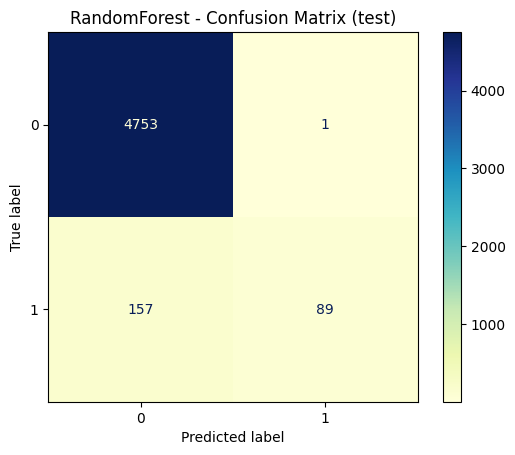

In [22]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="YlGnBu")
plt.title(f"{best_label} - Confusion Matrix (test)")
plt.savefig("artifacts/figures/confusion_matrix.png")
plt.show()

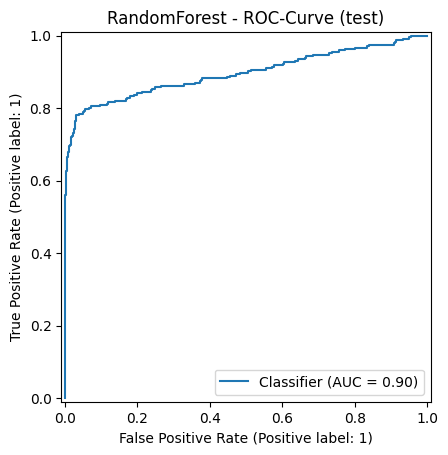

In [23]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.title(f"{best_label} - ROC-Curve (test)")
plt.savefig("artifacts/figures/roc_curve.png")
plt.show()

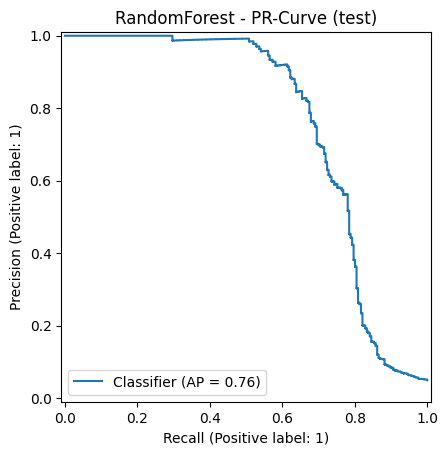

In [24]:
PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba)
plt.title(f"{best_label} - PR-Curve (test)")
plt.savefig("artifacts/figures/pr_curve.png")
plt.show()

### 6. Интерпретация

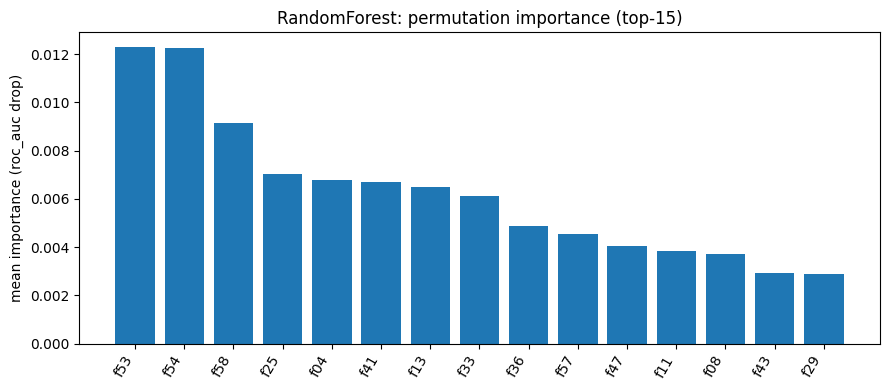

In [25]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=8,
    random_state=RANDOM_STATE,
    scoring="roc_auc"
)

imp = perm.importances_mean
idx = np.argsort(imp)[::-1][:15]

plt.figure(figsize=(9, 4))
plt.bar(range(len(idx)), imp[idx])
plt.xticks(range(len(idx)), [feature_names[i] for i in idx], rotation=60, ha="right")
plt.ylabel("mean importance (roc_auc drop)")
plt.title(f"{best_label}: permutation importance (top-15)")
plt.tight_layout()
plt.savefig("artifacts/figures/permutation_importance.png")
plt.show()

Интерпретировать влияние признаков в данном случае сложно из-за их обезличенных названий.

### 7. Сохранение артефактов

In [26]:
metadata_dict = {
        "project": "HW06",
        "dataset": "S06-hw-dataset-04.csv",
        "version": "1.0"
    }

results_dict = df_results.set_index("model").to_dict(orient="index")

output = {
    "metadata": metadata_dict,
    "results": results_dict
}

with open("artifacts/metrics_test.json", "w", encoding="utf-8") as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

In [27]:
with open("artifacts/search_summaries.json", "w", encoding="utf-8") as f:
    json.dump(search_summaries, f, ensure_ascii=False, indent=2)

In [28]:
joblib.dump(best_model, "artifacts/best_model.joblib")

['artifacts/best_model.joblib']

In [29]:
best_model_meta = {
    best_label: {
        "test_metrics": best_row.drop("model").to_dict(),
        "search_summary": search_summaries.get(best_label, None),
        "random_state": RANDOM_STATE,
    }
}

with open("artifacts/best_model_meta.json", "w", encoding="utf-8") as f:
    json.dump(best_model_meta, f, ensure_ascii=False, indent=2)